# Investigating QD features that make them potentially less-detectable

This part of the notebook is also best ran in venv-afm. Some sells at the start of the notebook will have to be re-run... and it is sometimes random. Im still not sure why even though I'm using venv-afm all the time, this notebook just forgets some cells between sections. But may prpbably be my computer-s memory?

First, we need to sort out all the connections before the files: 

1. Find Project Root

In [1]:
import sys
from pathlib import Path 

PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
    and (PROJECT_ROOT / "Ground-Truth").exists()
    and (PROJECT_ROOT / "QD-Analysis").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")

    PROJECT_ROOT = PROJECT_ROOT.parent

2. List Project Directories

In [2]:
DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"
QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"

CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
BIOLOGY_DIR = DETECTION_DIR / "Biology-Inspired"
CNN_DIR = DETECTION_DIR / "Binary-Unet"

3. Import Locations

In [3]:
for path in [
    PROJECT_ROOT,
    DETECTION_DIR,
    PREPROCESSING_DIR,
    GROUND_TRUTH_DIR,
    QD_ANALYSIS_DIR,
    CLASSICAL_DIR,
    BIOLOGY_DIR,
    CNN_DIR,
]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)


print("PROJECT_ROOT:", PROJECT_ROOT)

QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"
sys.path.insert(0, str(QD_ANALYSIS_DIR))

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


4. Include all the libraries

In [4]:
import numpy as np
import pandas as pd

from scipy.ndimage import binary_dilation
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from skimage.measure import label, regionprops

import QD_analysis as qa


5. Include related notebooks so that we can avoid redefining scans 

In [5]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from skimage.feature import blob_log
from skimage.filters import gaussian
from skimage.restoration import denoise_tv_chambolle

from skimage.filters import sobel, threshold_otsu 
from skimage.morphology import remove_small_objects 

from scipy.ndimage import gaussian_laplace

from skimage.filters import threshold_multiotsu
from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

In [6]:
%%capture
%run "./pit_distribution_analysis.ipynb"

In [8]:
dataset = {}

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    ground_truth_centres = qa.centres_from_binary_mask(mask)

    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": ground_truth_centres,
    }

extract_qd_features function extracts the features the dot on an image based on the ground truth scan and tells its parameters. Since we have too many dots, the data is in a table. 

Anyway, a more visual analysis is presented at the botton of this notebook.

In [9]:
scan_name = "Scan3"

image = dataset[scan_name]["processed"]
gt_mask = dataset[scan_name]["ground_truth_mask"]

qd_df = qa.extract_qd_features(image, gt_mask)

display(qd_df)

,qd_id,cy,cx,height,area,radius,local_contrast,local_background_std,local_background_mad,nearest_qd_distance,edge_distance
0,1,2.229167,135.000000,1.081105e-09,48.0,3.908820,4.438265e-10,4.460946e-10,2.516034e-10,47.543954,2.229167
1,2,2.857143,294.836735,1.339987e-09,49.0,3.949327,7.982035e-10,1.216660e-10,1.170477e-10,32.855406,2.857143
2,3,9.602151,365.645161,1.445603e-09,93.0,5.440847,6.824901e-10,1.146916e-10,1.051343e-10,36.706249,9.602151
3,4,9.697368,459.736842,1.238808e-09,76.0,4.918491,5.836626e-10,1.327320e-10,1.406384e-10,26.502420,9.697368
4,5,10.000000,61.000000,7.638290e-10,69.0,4.686511,3.295853e-10,2.786722e-10,2.145543e-10,25.407142,10.000000
...,...,...,...,...,...,...,...,...,...,...,...
130,131,488.678571,274.214286,2.454789e-09,84.0,5.170883,1.469194e-09,2.601259e-10,2.674525e-10,33.941219,22.321429
131,132,489.890909,27.363636,6.910996e-10,55.0,4.184142,3.282709e-10,1.368252e-10,1.314079e-10,41.518224,21.109091
132,133,490.000000,321.000000,1.074014e-09,69.0,4.686511,6.679498e-10,4.459091e-10,3.050733e-10,28.756584,21.000000
133,134,498.162791,429.372093,1.548545e-09,86.0,5.232079,7.339950e-10,2.761271e-10,2.958163e-10,36.279392,12.837209


Properly match predictions to GT QDs (this uses Hungarian matching) and function is again defined in the QD_analysis.py file.

Call all of the algorithm-related functions.

0.1 Laplacian of Gaussian

In [10]:
log_results = da.log_detect(
    raw,
    processed,
    destriped=True,
    smoothing=True,
    gaussian_sigma=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.2 Chambolle anisotropic diffusion smoothing instead of Gaussian smoothing used in the above function

In [11]:
cad_results = da.chambolle_anisotropic_diffusion_detect(
    raw,
    processed,
    destriped=True,
    smoothing=True,
    diffusion_weight=0.08,
    max_num_iter=200,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.3 QD detection via Otsu threshold being used in LoG

In [12]:
otsu_results = da.otsu_detect(
    raw,
    processed,
    destriped=True,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    overlap=0.5,
    minimum_height=6e-10,
)

0.4 Hough Transform Detection 

In [13]:
ht_results = da.hough_transform_detect(
    raw,
    processed,
    destriped=True,
    canny_sigma=1,
    min_radius=2,
    max_radius=8,
    min_xdistance=5,
    min_ydistance=5,
    threshold_relative=0.73,
    normalize=True,
    minimum_height=6e-10,
)

0.5 Perona Maulik anisotropic diffusion 

In [14]:
pmab_results = da.peronamalik_anisotropic_diffusion_detect(
    raw,
    processed,
    destriped=True,
    smoothing=True,
    low_sigma=5,
    high_sigma=40,
    n_iterations=15,
    kappa=0.4,
    gamma=0.15,
    option=1,
    min_sigma=2,
    max_sigma=8,
    num_sigma=20,
    threshold=0.4,
    minimum_height=6e-10,
)

0.6 Phase congruency/ phase symmetry 

In [15]:
pc_results = da.detect_qds_phase_symmetry(
    raw,
    processed,
    destriped=True,
    nscale=6,
    min_wavelength=1.5,
    mult=9.0,
    noise_k=2.5,
    symmetry_threshold=0.08,
    min_distance=3,
    minimum_height=6e-10,
)

0.7 SIFT detection 

In [16]:
sift_results = da.sift_detect(
    raw,
    processed,
    destriped=True,
    background_sigma=10,
    qd_min_sigma=0.8,
    qd_max_sigma=4.0,
    upsampling=2,
    n_octaves=3,
    n_scales=5,
    sigma_min=2,
    sigma_in=0.5,
    c_dog=0.05,
    c_edge=15,
    lower_percentile=1,
    upper_percentile=99,
    minimum_height=6e-10,
)

0.10 Watershed detection 

In [17]:
ws_results = da.watershed_detect(
    raw,
    processed,
    destriped=True,
    footprint_radius=6,
    min_size=1,
    min_distance=3,
    min_area=5,
    minimum_height=6e-10,
)

/Users/polinabobrova/Desktop/GaN Quantum Dot Analysis/Detection/Classical-Optimised/detection_algorithms.py:701: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  qd_mask = remove_small_objects(processed_image > threshold, min_size=min_size)


0.11 Using Gabor wavelets for QD detection -> this takes longest to execute by time 

In [18]:
gw_results = da.gabor_detect(
    raw,
    processed,
    destriped=True,
    smoothing_sigma=0.58,
    top_hat_radius=6,
    wavelengths=(2, 3, 4, 5, 6, 8),
    number_of_orientations=8,
    bandwidth=1.0,
    threshold_percentile=90,
    min_distance=2,
    minimum_height=6e-10,
)

## 2. Object-level detection metrics 

This will help identifying if the algorithms managed to find the correct dots - this compares predicted and real centres 

In [20]:
algorithm_results = {
    "LoG": log_results,
    "CAD": cad_results,
    "Otsu": otsu_results,
    "HT": ht_results,
    "PMAD": pmab_results,
    "PC": pc_results,
    "SIFT": sift_results,
    "WS": ws_results,
    "GW": gw_results,
}

In [22]:
import importlib
import QD_analysis as qa

importlib.reload(qa)

for algorithm_name, result in algorithm_results.items():
    noerror_name = (algorithm_name.lower().replace(" ", "_").replace("-", "_"))

    # BEFORE HEIGHT FILTER
    before_centres = result["before_height_filter"]["centres"]
    detected_before, distance_before = (qa.match_detections(qd_df, before_centres, tolerance=3.0))

    qd_df[f"{noerror_name}_before"] = detected_before
    qd_df[f"{noerror_name}_before_distance"] = distance_before

    # AFTER HEIGHT FILTER
    after_centres = result["after_height_filter"]["centres"]
    detected_after, distance_after = (qa.match_detections(qd_df, after_centres, tolerance=3.0))

    qd_df[f"{noerror_name}_after"] = detected_after
    qd_df[f"{noerror_name}_after_distance"] = distance_after

In [23]:
display(qd_df)

,qd_id,cy,cx,height,area,radius,local_contrast,local_background_std,local_background_mad,nearest_qd_distance,...,sift_after,sift_after_distance,ws_before,ws_before_distance,ws_after,ws_after_distance,gw_before,gw_before_distance,gw_after,gw_after_distance
0,1,2.229167,135.000000,1.081105e-09,48.0,3.908820,4.438265e-10,4.460946e-10,2.516034e-10,47.543954,...,False,NaN,False,NaN,False,NaN,True,2.443191,True,2.443191
1,2,2.857143,294.836735,1.339987e-09,49.0,3.949327,7.982035e-10,1.216660e-10,1.170477e-10,32.855406,...,False,NaN,False,NaN,False,NaN,True,1.864306,True,1.864306
2,3,9.602151,365.645161,1.445603e-09,93.0,5.440847,6.824901e-10,1.146916e-10,1.051343e-10,36.706249,...,True,0.533099,True,0.533099,True,0.533099,True,0.533099,True,0.533099
3,4,9.697368,459.736842,1.238808e-09,76.0,4.918491,5.836626e-10,1.327320e-10,1.406384e-10,26.502420,...,True,0.796569,True,0.796569,True,0.796569,True,0.796569,True,0.796569
4,5,10.000000,61.000000,7.638290e-10,69.0,4.686511,3.295853e-10,2.786722e-10,2.145543e-10,25.407142,...,False,NaN,True,0.000000,True,0.000000,False,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,131,488.678571,274.214286,2.454789e-09,84.0,5.170883,1.469194e-09,2.601259e-10,2.674525e-10,33.941219,...,True,1.338690,True,1.338690,True,1.338690,True,0.848919,True,0.848919
131,132,489.890909,27.363636,6.910996e-10,55.0,4.184142,3.282709e-10,1.368252e-10,1.314079e-10,41.518224,...,False,NaN,True,0.645647,True,2.500645,False,NaN,False,NaN
132,133,490.000000,321.000000,1.074014e-09,69.0,4.686511,6.679498e-10,4.459091e-10,3.050733e-10,28.756584,...,False,NaN,True,0.000000,True,0.000000,True,0.000000,True,0.000000
133,134,498.162791,429.372093,1.548545e-09,86.0,5.232079,7.339950e-10,2.761271e-10,2.958163e-10,36.279392,...,False,NaN,True,2.252095,True,2.252095,True,2.252095,True,2.252095


for a reason, I've been having issues with displaying the names of the algorithms. So have decided to have some lines dedicated to deleting a couple of problematic symbols.

In [24]:
algorithm_names = []

for algorithm_name, result in algorithm_results.items():
    noerror_name = (algorithm_name.lower().replace(" ", "_").replace("-", "_"))

    algorithm_names.append(noerror_name)

    before = qd_df[f"{noerror_name}_before"]
    after = qd_df[f"{noerror_name}_after"]

    qd_df[f"{noerror_name}_status"] = np.select(
        [~before, before & ~after, after],
        ["detector_miss", "removed_by_height_filter", "detected"],
        default="unknown",
    )

In [25]:
missed_by_algorithm = {}

for noerror_name in algorithm_names:

    missed = qd_df[qd_df[f"{noerror_name}_after"] == False].copy()
    missed_by_algorithm[ algorithm_name] = missed

    print(f"{algorithm_name}: "f"{len(missed)} / {len(qd_df)} missed")

GW: 43 / 135 missed
GW: 42 / 135 missed
GW: 38 / 135 missed
GW: 113 / 135 missed
GW: 83 / 135 missed
GW: 62 / 135 missed
GW: 75 / 135 missed
GW: 26 / 135 missed
GW: 39 / 135 missed


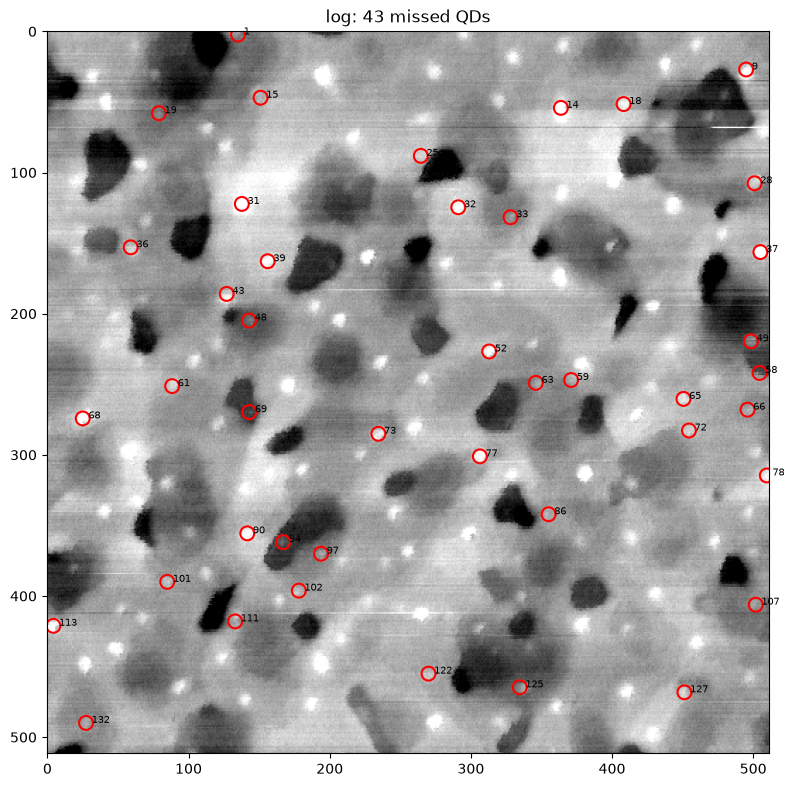

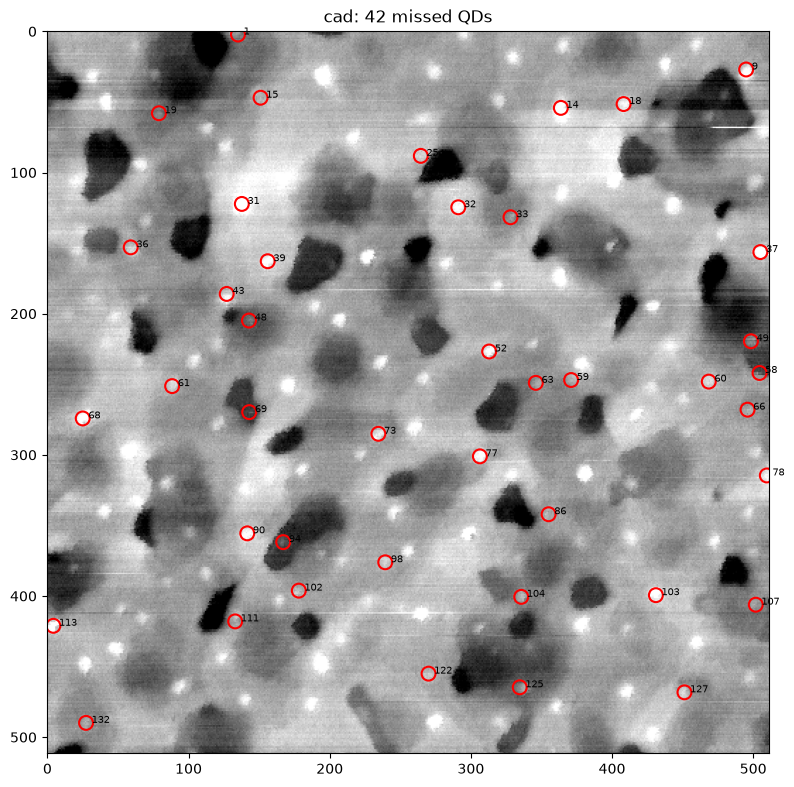

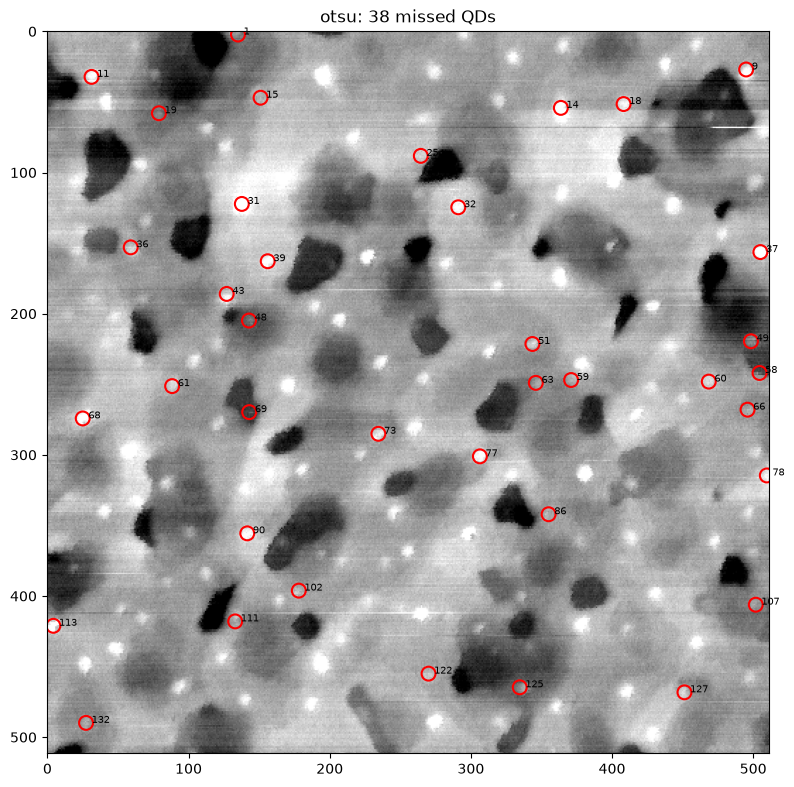

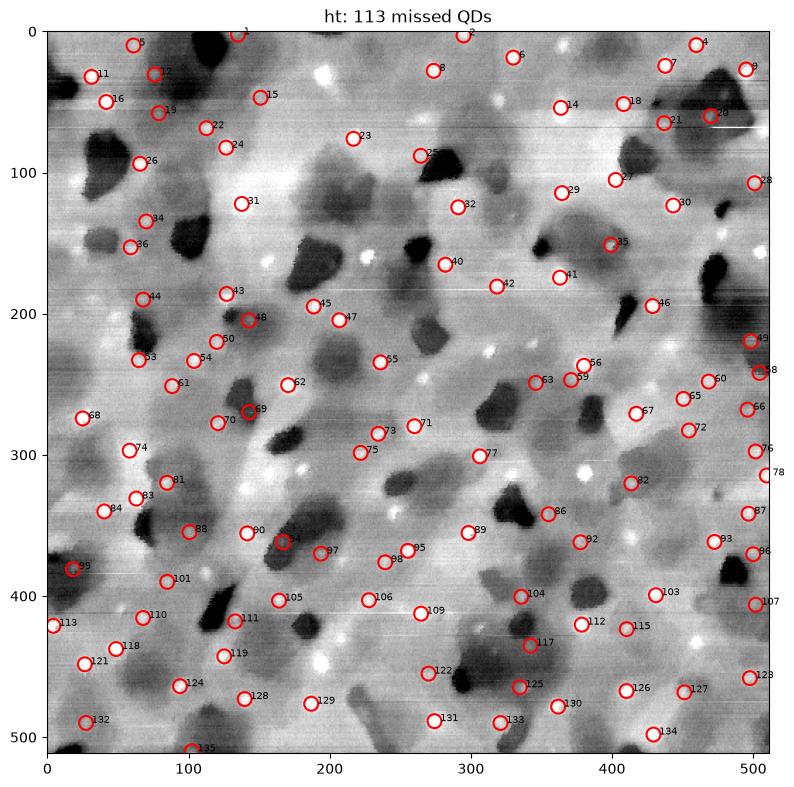

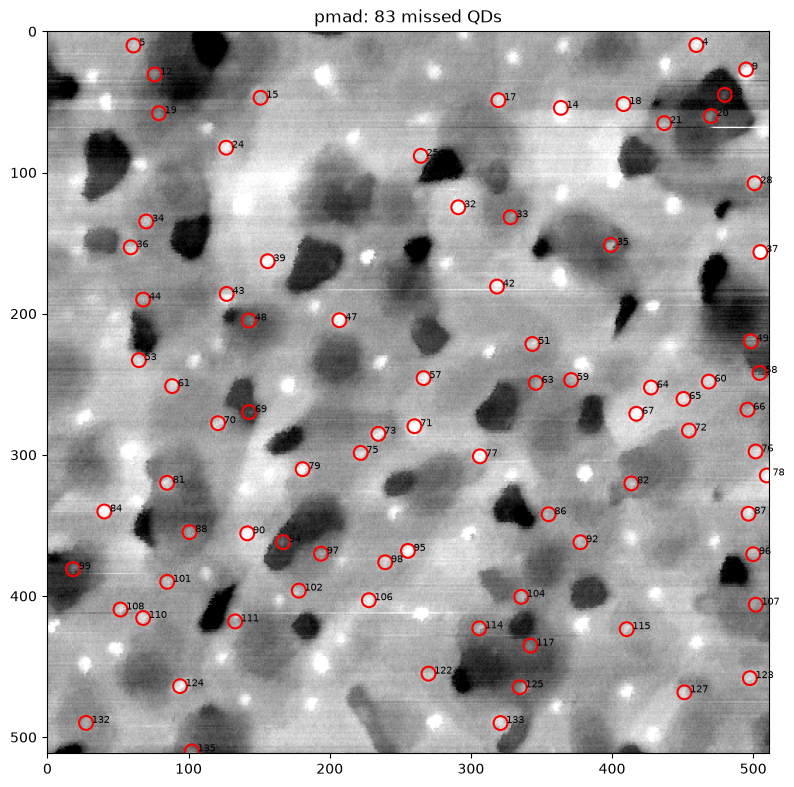

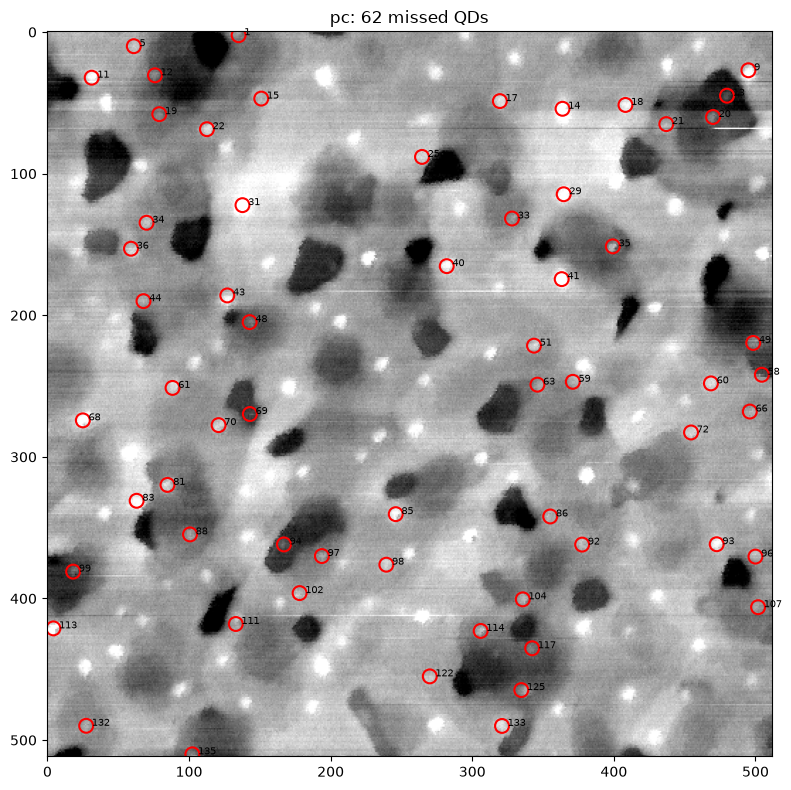

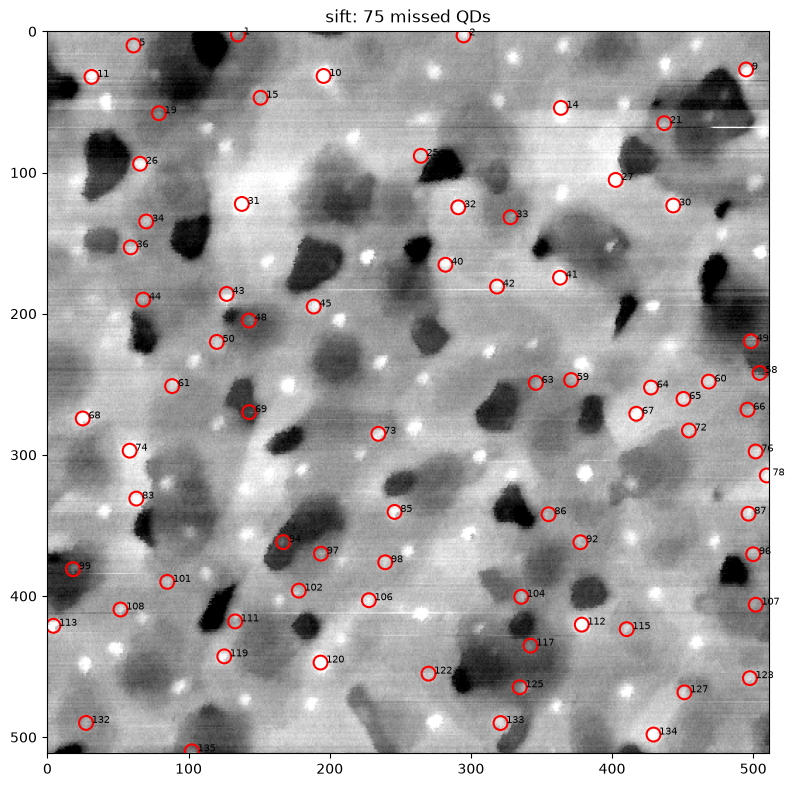

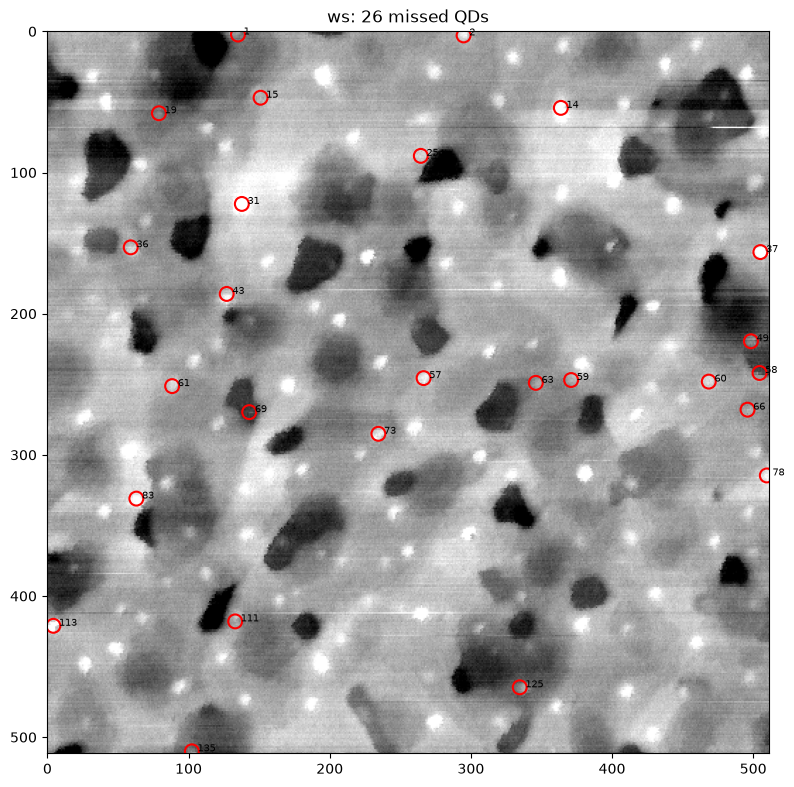

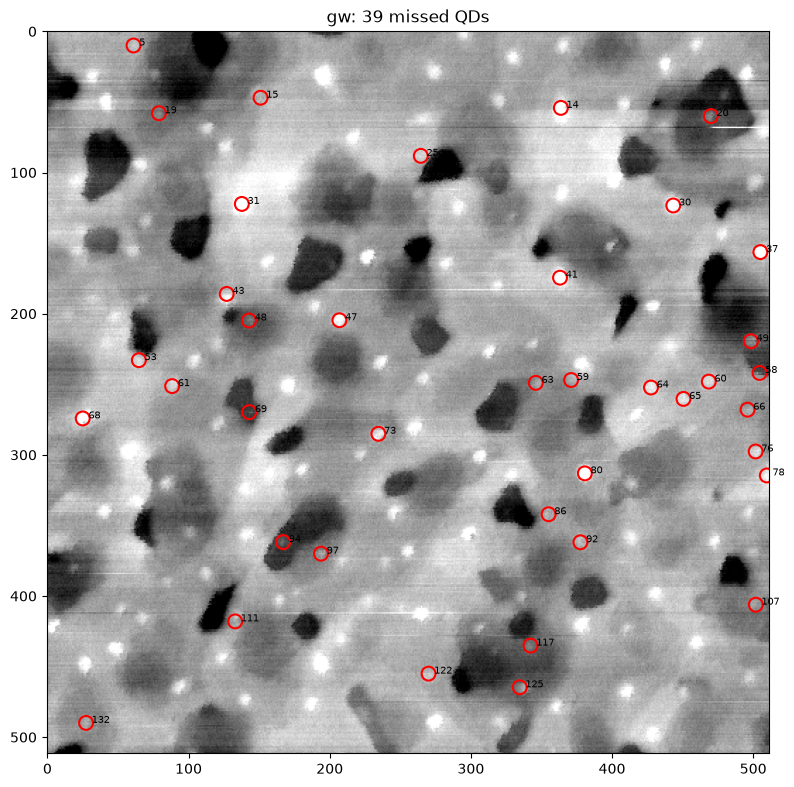

In [ ]:
for noerror_name in algorithm_names:

    qa.plot_missed_qds(
        image,
        qd_df,
        noerror_name,
    )

In [31]:
from scipy.stats import pointbiserialr

features = [
    "height",
    "radius",
    "area",
    "local_contrast",
    "local_background_std",
    "local_background_mad",
    "nearest_qd_distance",
    "edge_distance",
]

correlation_rows = []

for noerror_name in algorithm_names:
    detection = qd_df[f"{noerror_name}_after"].astype(int)

    for feature in features:
        values = qd_df[feature]
        valid = (np.isfinite(values) & np.isfinite(detection))

        if valid.sum() < 3:
            continue

        # Correlation is undefined if every QD has exactly the same detection status
        if detection[valid].nunique() < 2:
            continue

        r, p = pointbiserialr(detection[valid], values[valid])

        correlation_rows.append({
            "algorithm": noerror_name,
            "feature": feature,
            "correlation": r,
            "p_value": p,
        })

correlation_df = pd.DataFrame(correlation_rows)

display(correlation_df)

,algorithm,feature,correlation,p_value
0,log,height,0.313095,0.000218
1,log,radius,0.202276,0.018635
2,log,area,0.177039,0.039963
3,log,local_contrast,0.309144,0.000264
4,log,local_background_std,-0.131361,0.128845
...,...,...,...,...
67,gw,local_contrast,0.316768,0.000182
68,gw,local_background_std,-0.200158,0.019933
69,gw,local_background_mad,-0.190102,0.027215
70,gw,nearest_qd_distance,0.093613,0.280168


In [32]:
print(correlation_df.columns)
display(correlation_df.head())

Index(['algorithm', 'feature', 'correlation', 'p_value'], dtype='str')


,algorithm,feature,correlation,p_value
0,log,height,0.313095,0.000218
1,log,radius,0.202276,0.018635
2,log,area,0.177039,0.039963
3,log,local_contrast,0.309144,0.000264
4,log,local_background_std,-0.131361,0.128845


Sometimes the table below wasn't loading correctly. Pivot doesn't work for duplicates, so I added this function below. If errors occur again, use pivot_table() with the same arguments instead.. but then the table will likely be working with just one of the algorithms.

In [33]:
duplicates = correlation_df[
    correlation_df.duplicated(
        subset=["algorithm", "feature"],
        keep=False,
    )
]

display(duplicates)

,algorithm,feature,correlation,p_value


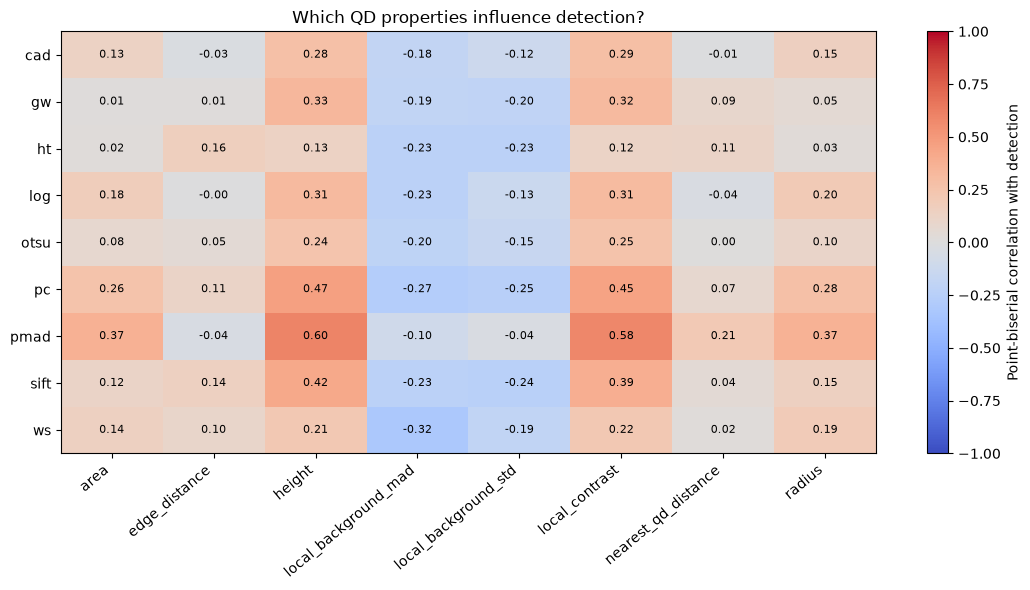

In [34]:
correlation_matrix = correlation_df.pivot(
    index="algorithm",
    columns="feature",
    values="correlation",
)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(correlation_matrix, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm",)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=40, ha="right",)
ax.set_yticks(np.arange(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Point-biserial correlation with detection")
ax.set_title("Which QD properties influence detection?")

plt.tight_layout()
plt.show()

r>0: larger feature value → more likely detected

r<0: larger feature value → more likely missed

r≈0: little linear relationship

∣r∣ closer to 1 → stronger relationship

In [45]:
print(algorithm_names)
print(correlation_df["algorithm"].unique())

['log', 'cad', 'otsu', 'ht', 'pmad', 'pc', 'sift', 'ws', 'gw']
<StringArray>
['log', 'cad', 'otsu', 'ht', 'pmad', 'pc', 'sift', 'ws', 'gw']
Length: 9, dtype: str


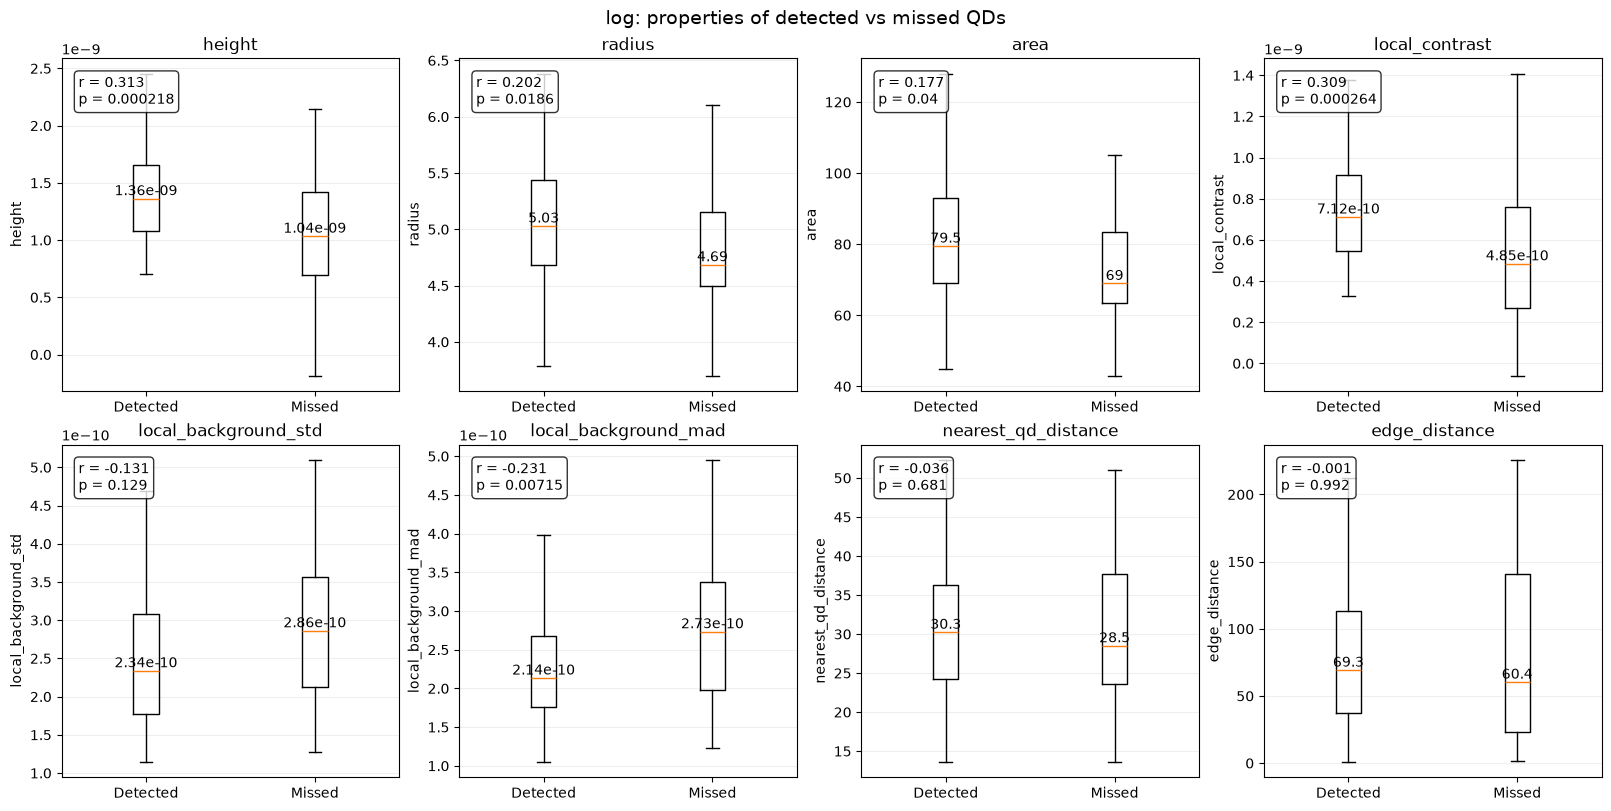

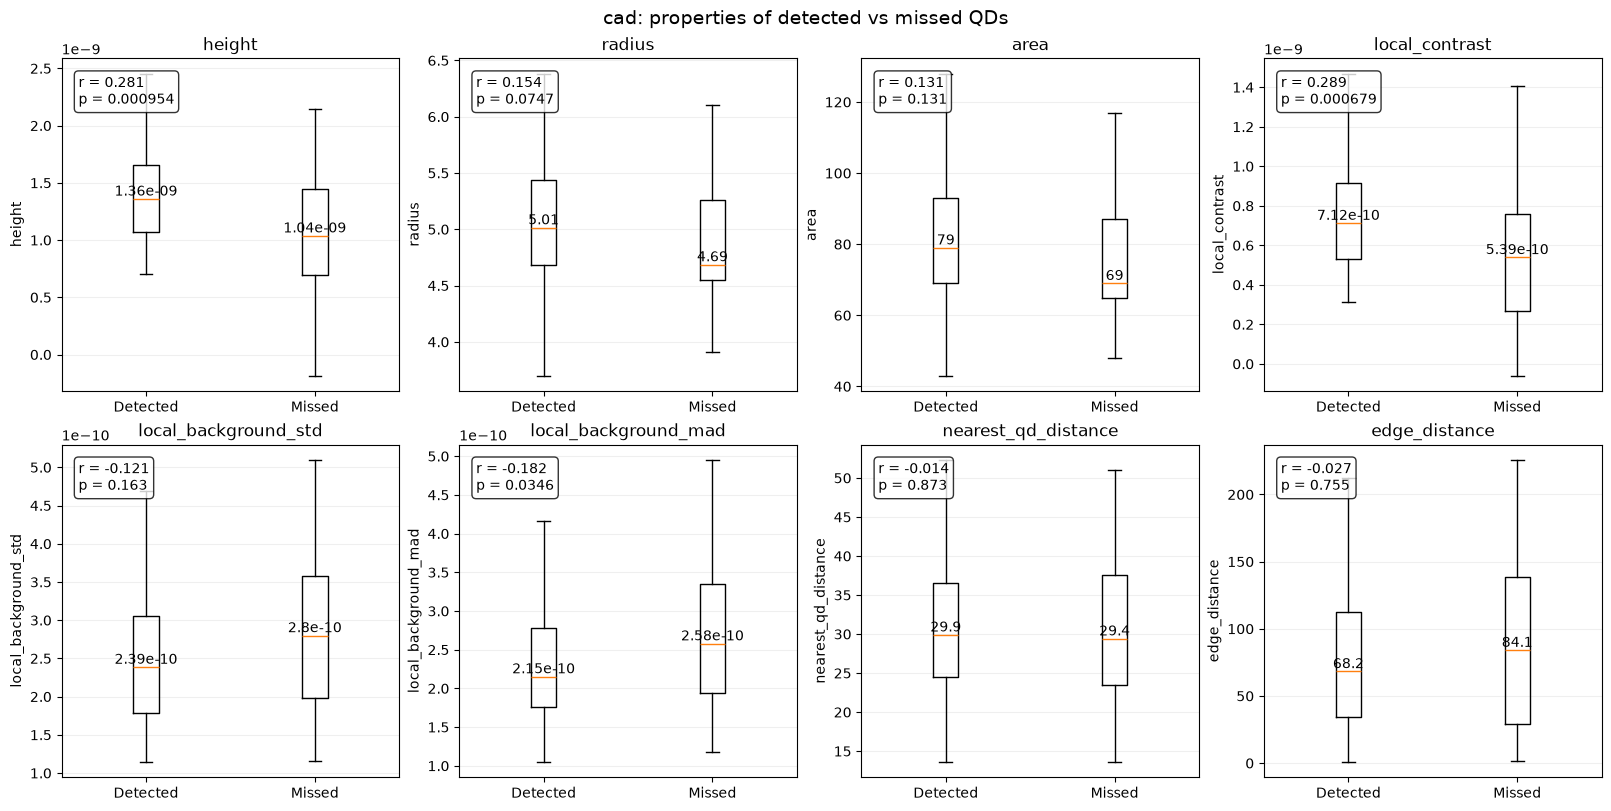

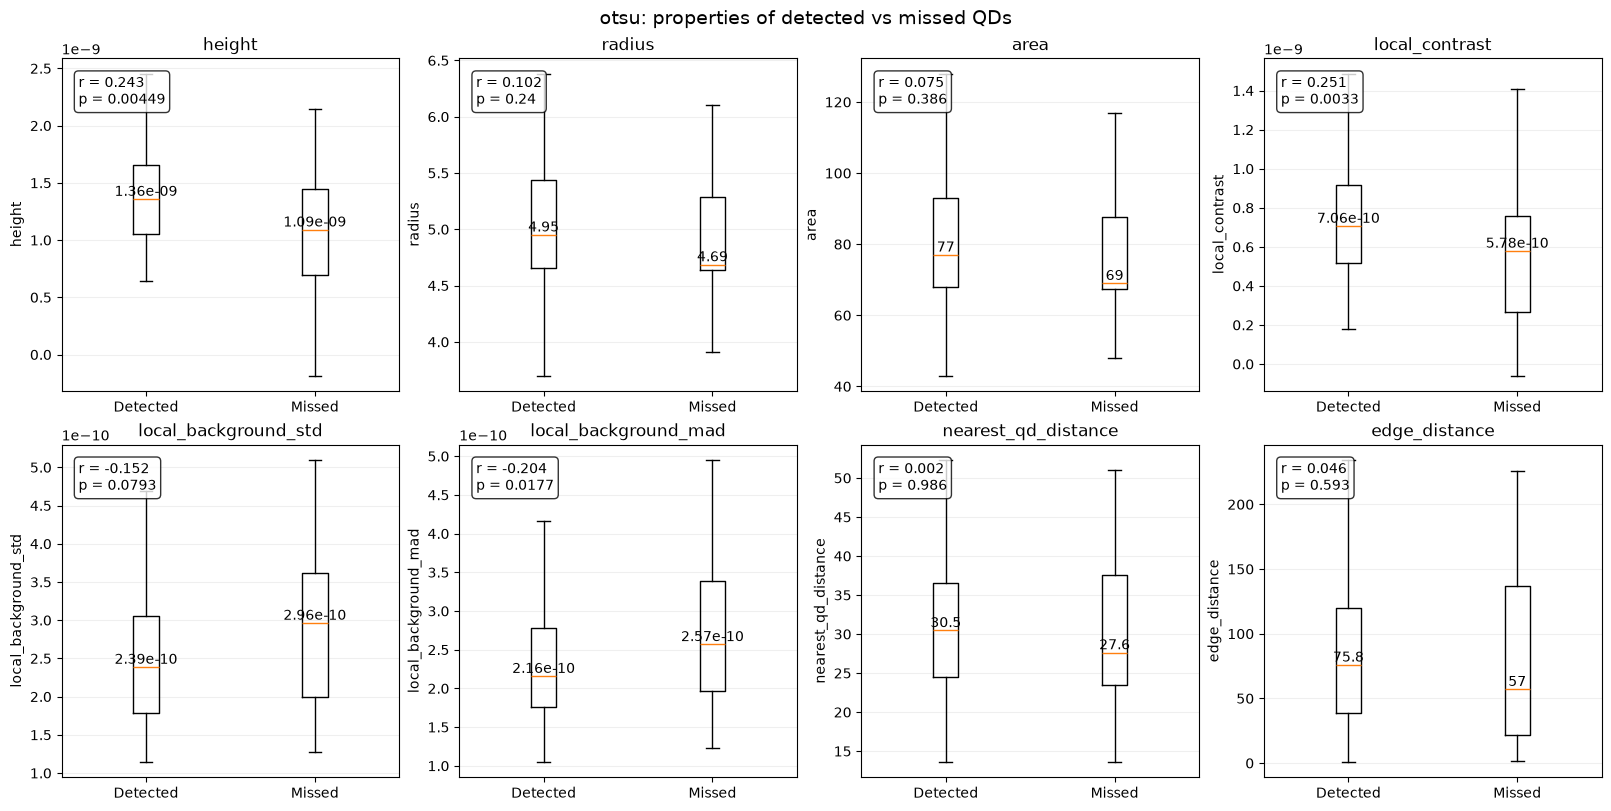

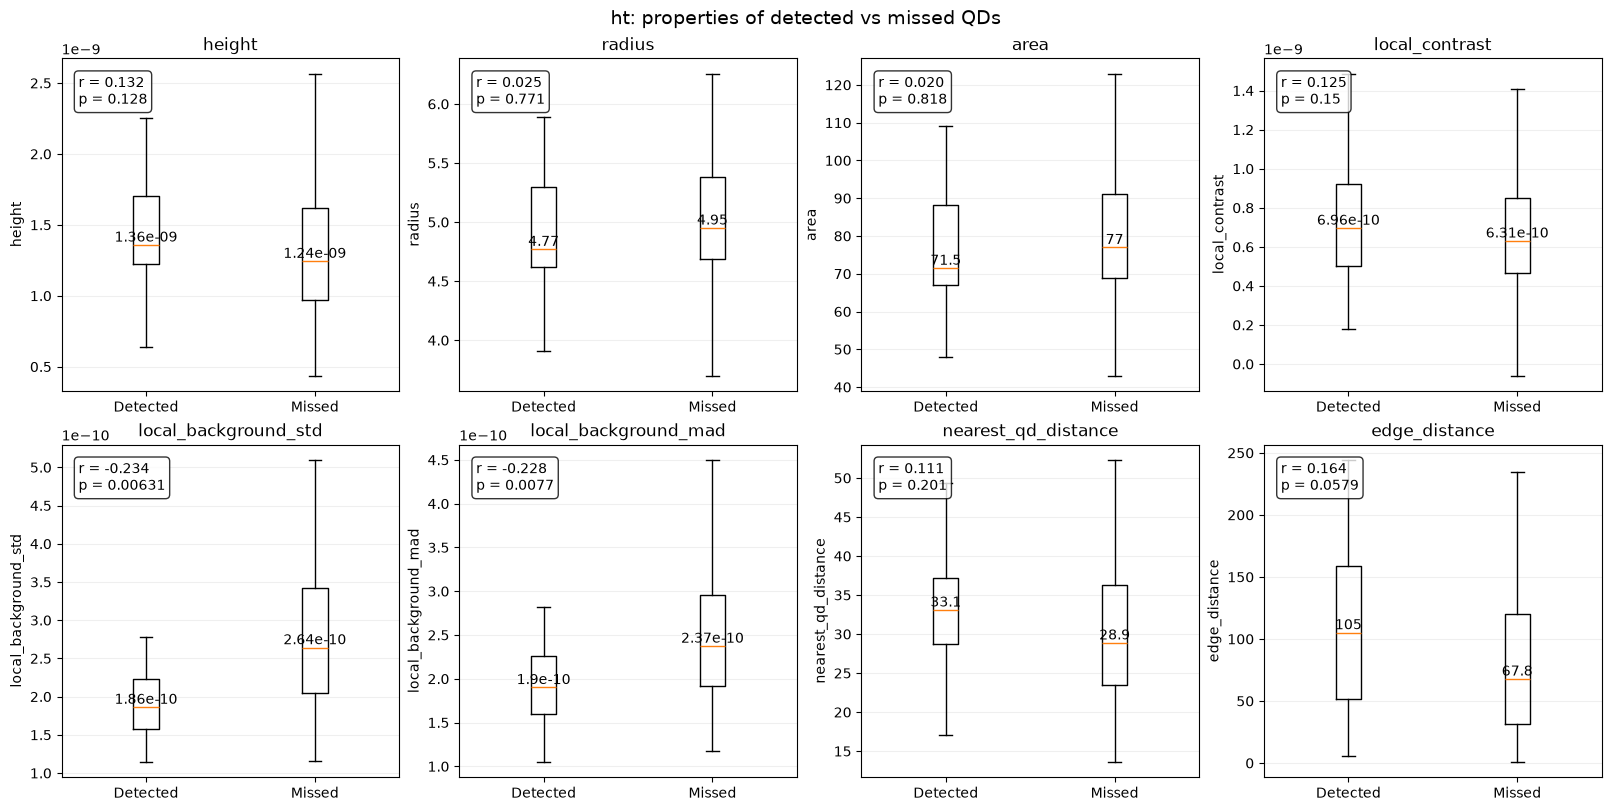

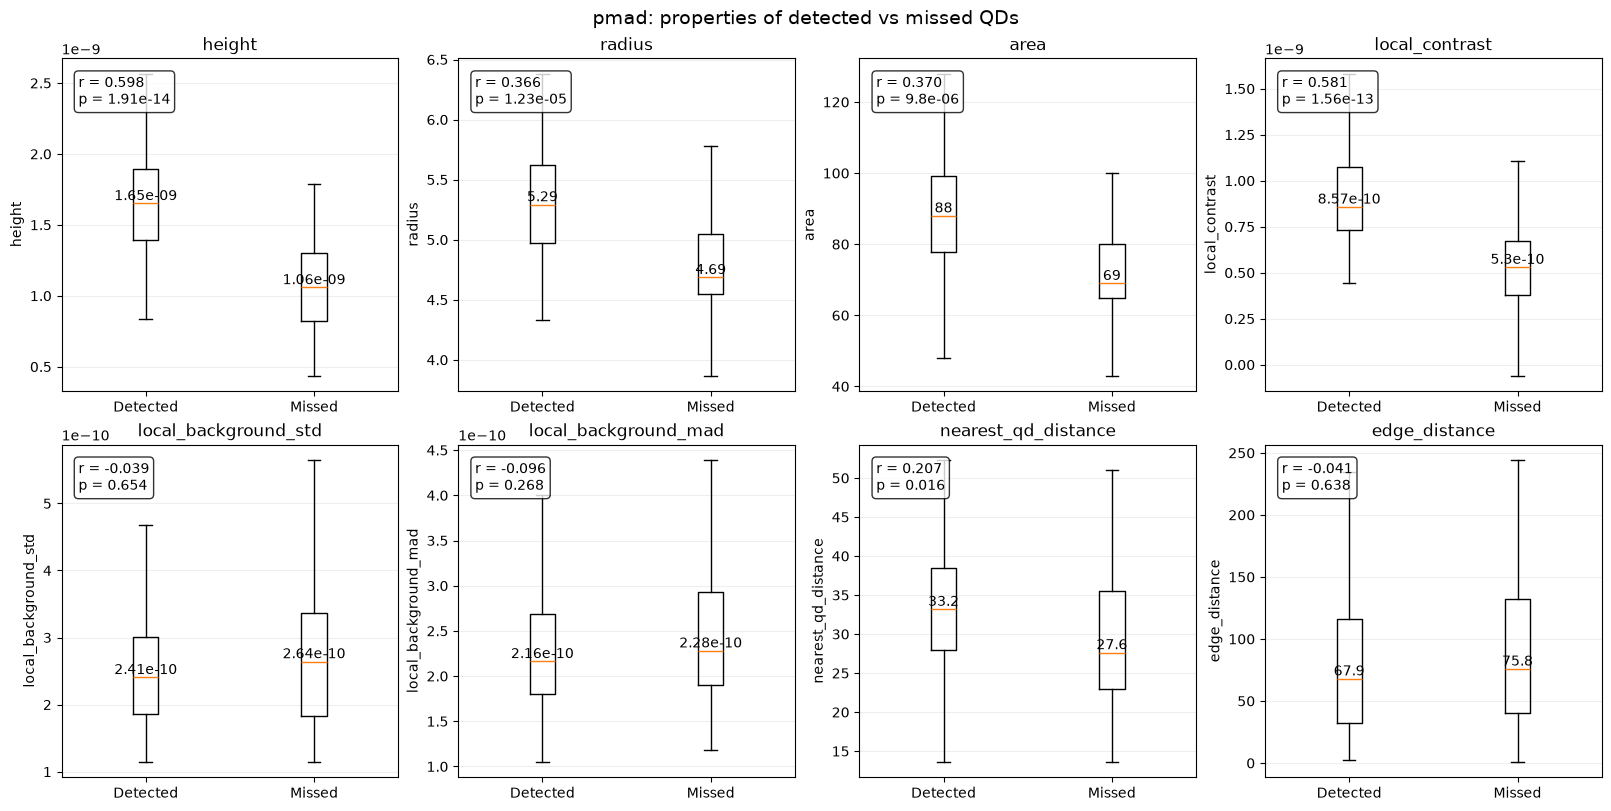

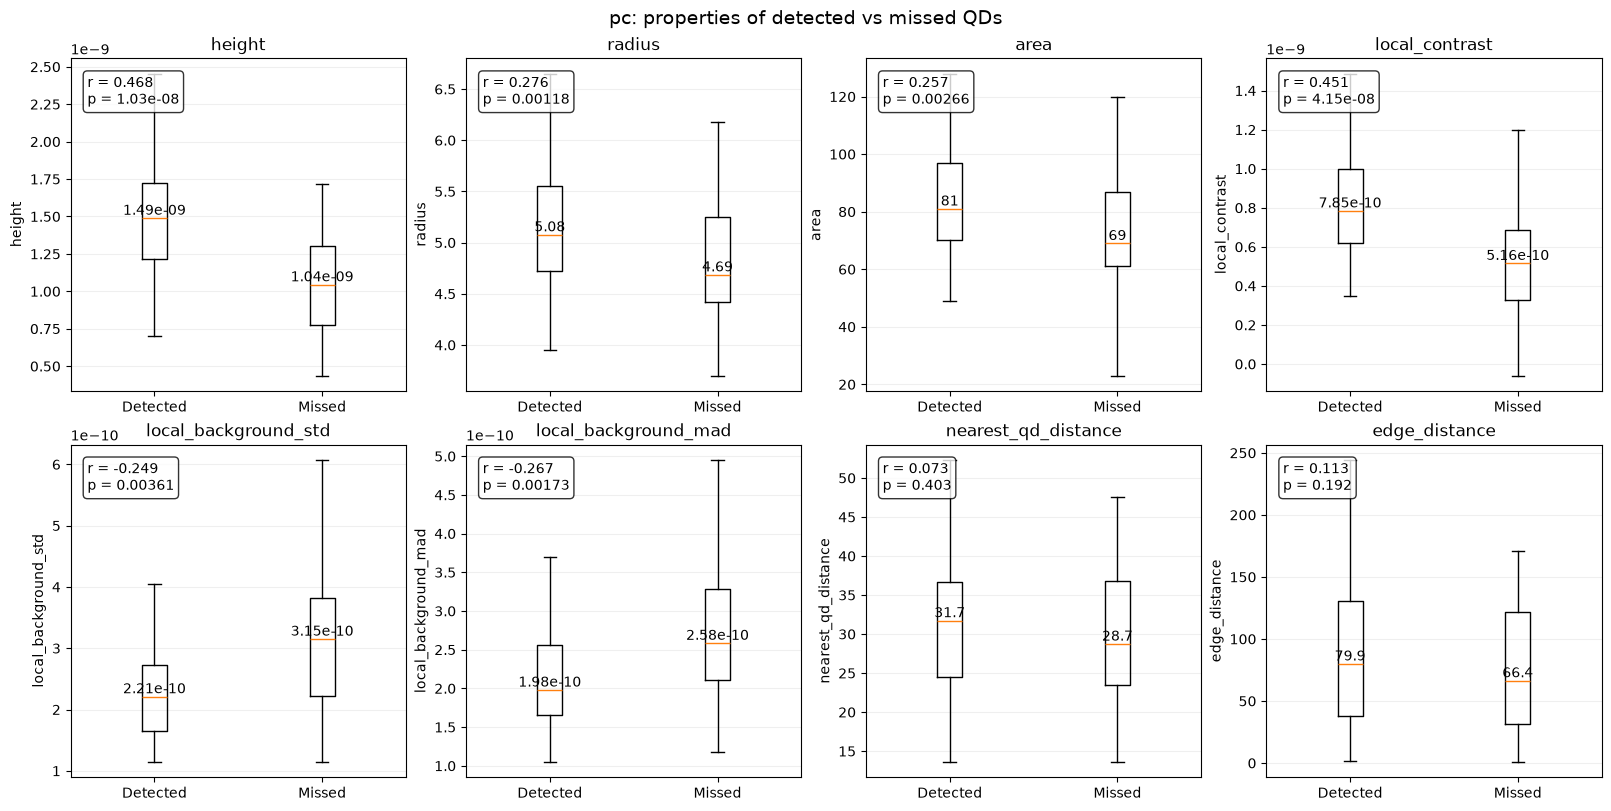

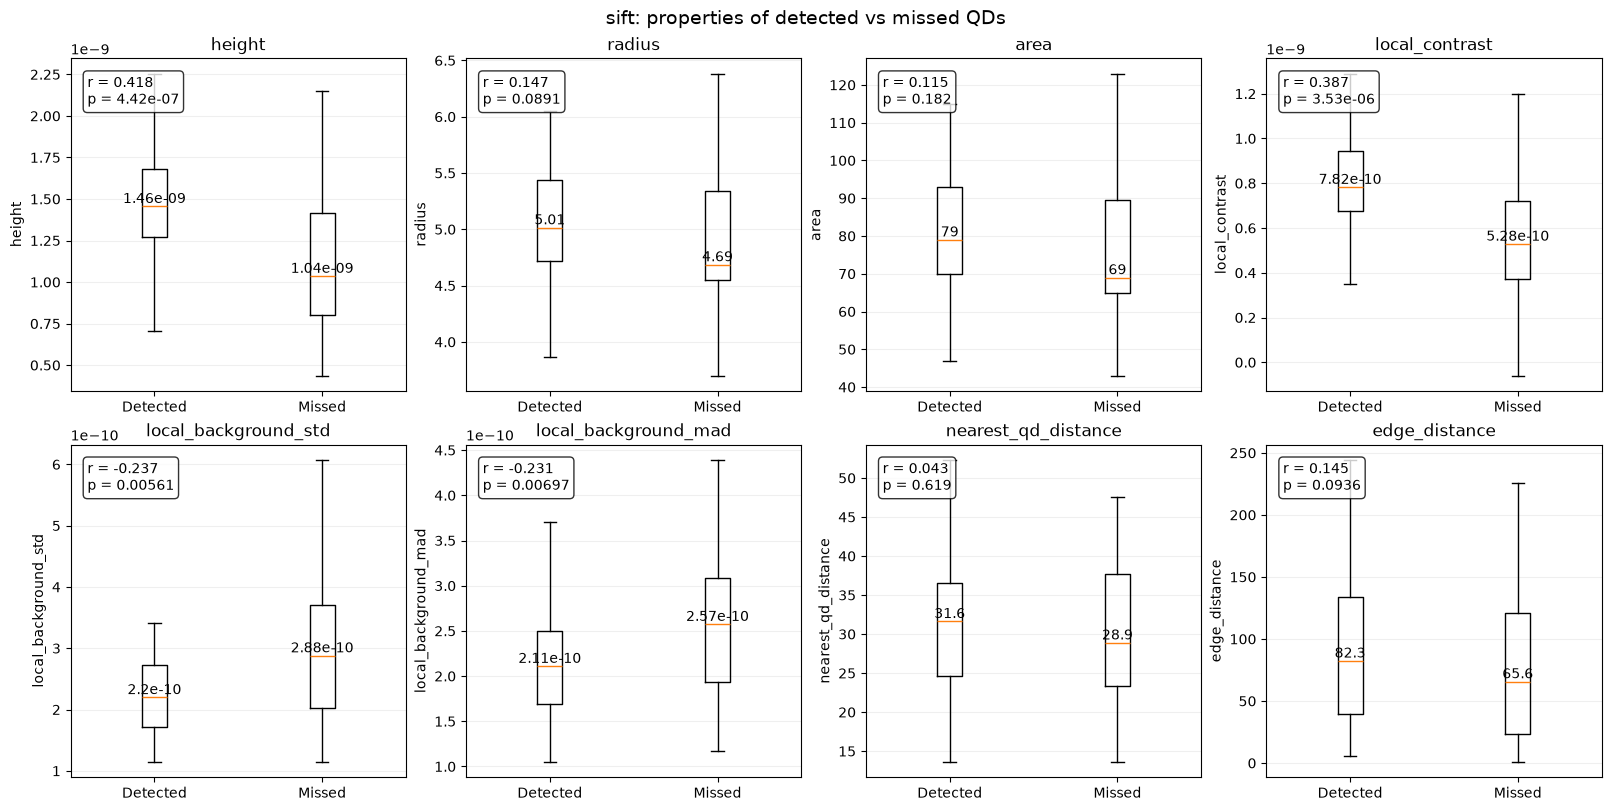

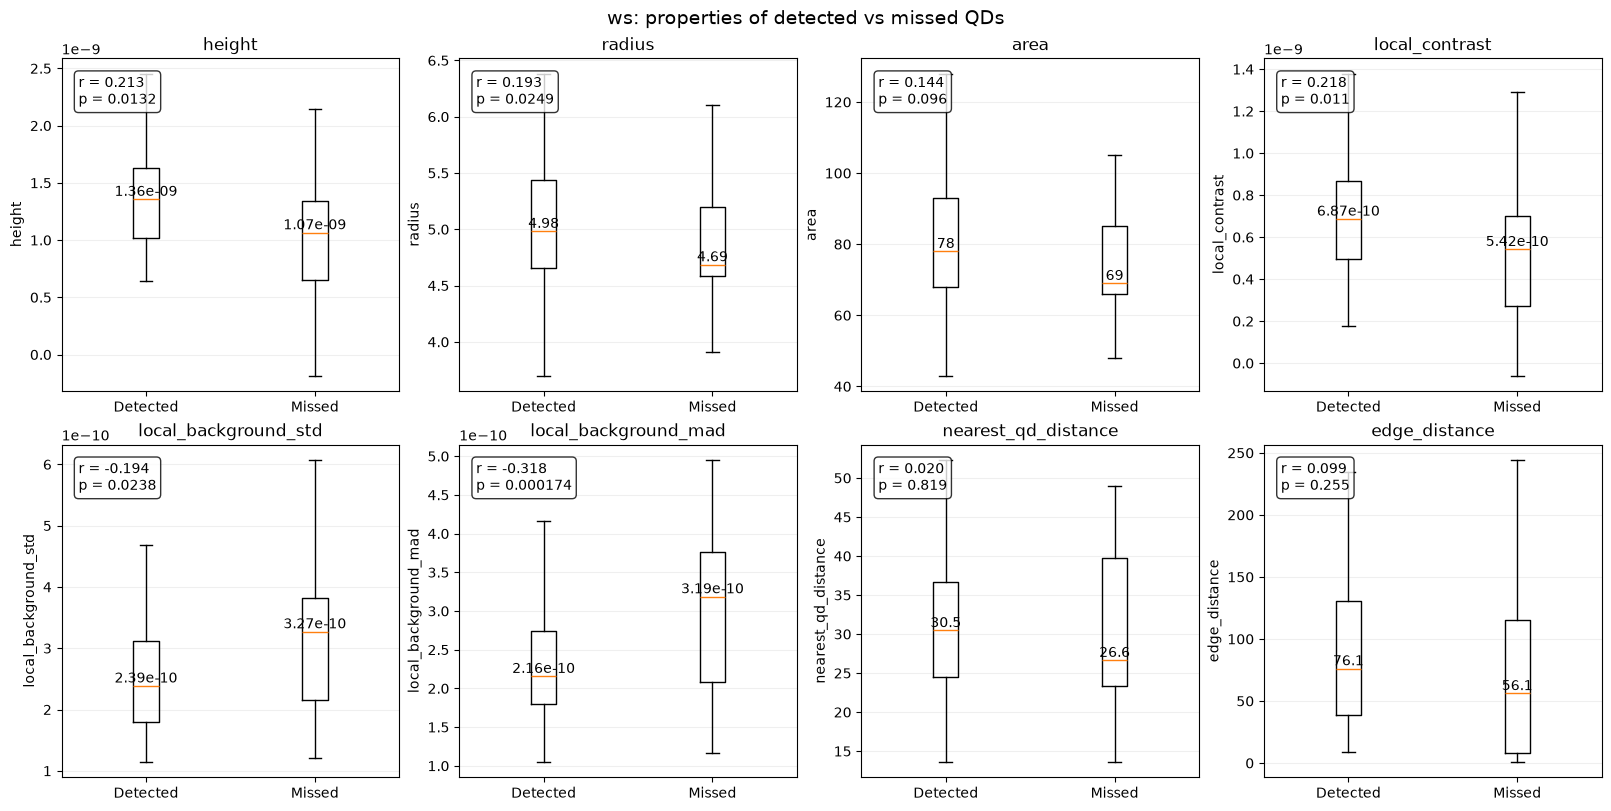

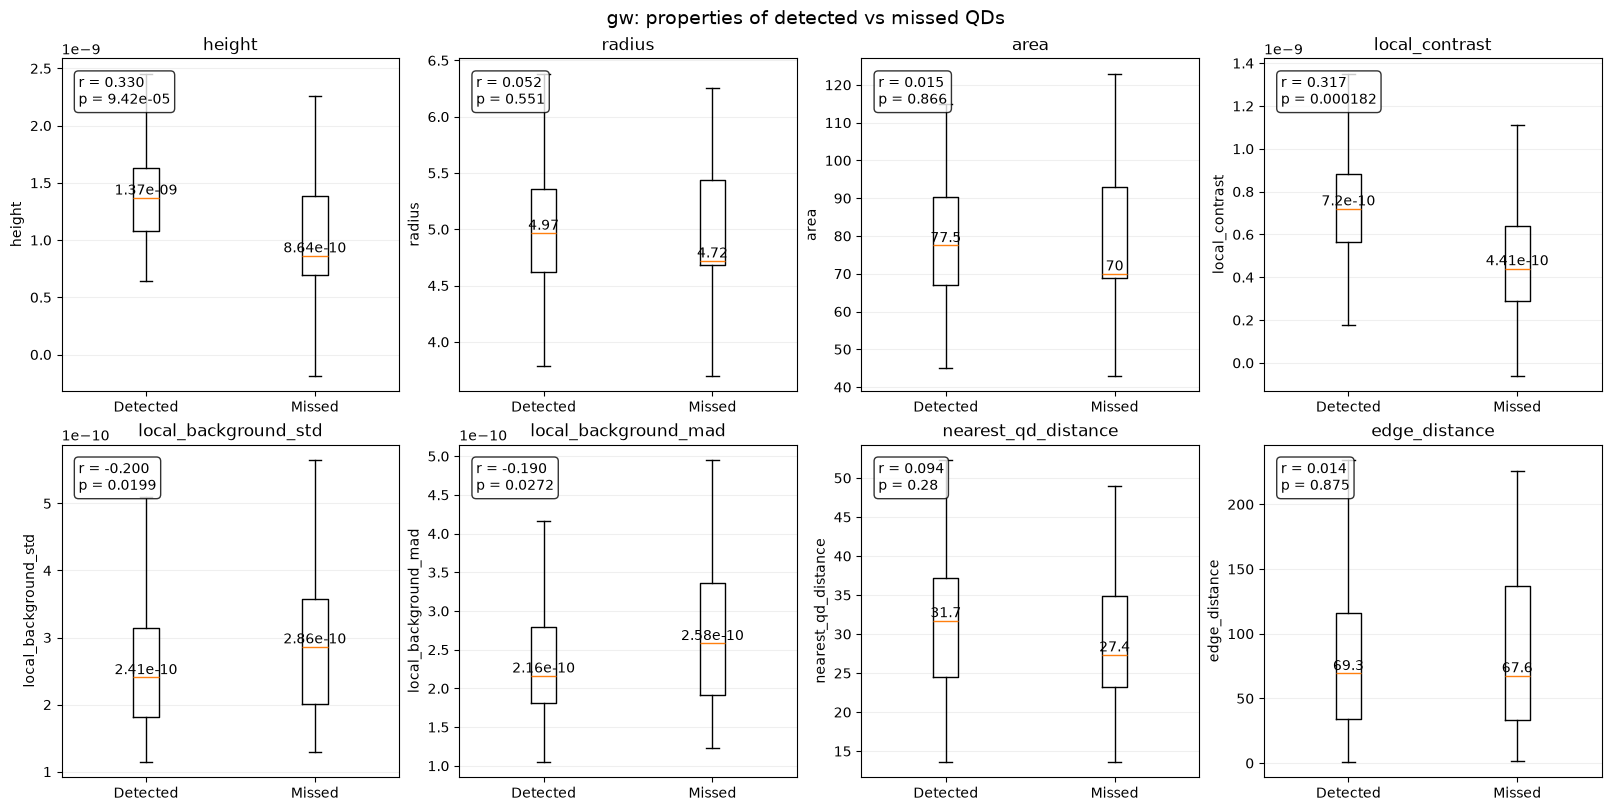

In [50]:
for noerror_name in algorithm_names:

    n_features = len(features)

    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)

    axes = np.atleast_1d(axes).ravel()

    # In case only one feature is used
    axes = np.atleast_1d(axes)

    for ax, feature in zip(axes, features):
        detected = qd_df.loc[qd_df[f"{noerror_name}_after"], feature,].dropna()
        missed = qd_df.loc[~qd_df[f"{noerror_name}_after"], feature,].dropna()

        # BOXPLOT
        ax.boxplot([detected, missed], tick_labels=["Detected", "Missed"], showfliers=False,)
        ax.set_title(feature)
        ax.set_ylabel(feature)
        ax.grid(axis="y", alpha=0.2)

        # GET CORRELATION VALUE
        correlation_row = correlation_df[(correlation_df["algorithm"] == noerror_name) & (correlation_df["feature"] == feature)]

        if not correlation_row.empty:
            r = correlation_row.iloc[0]["correlation"]
            p = correlation_row.iloc[0]["p_value"]

            # WRITE IT INSIDE THE GRAPH
            ax.text(
                0.05,
                0.95,
                f"r = {r:.3f}\np = {p:.3g}",
                transform=ax.transAxes,
                verticalalignment="top",
                horizontalalignment="left",
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    alpha=0.8,
                ),
            )

        # ALSO DISPLAY GROUP MEDIANS
        detected_median = np.nanmedian(detected)
        missed_median = np.nanmedian(missed)

        ax.text(1, detected_median, f"{detected_median:.3g}", ha="center", va="bottom")
        ax.text(2, missed_median, f"{missed_median:.3g}", ha="center", va="bottom",)

    fig.suptitle(f"{noerror_name}: properties of detected vs missed QDs", fontsize=14,)
    plt.show()

In [49]:
print(algorithm_names)

['log', 'cad', 'otsu', 'ht', 'pmad', 'pc', 'sift', 'ws', 'gw']


In [37]:
after_columns = [f"{noerror_name}_after" for noerror_name in algorithm_names]

qd_df["n_algorithms_detected"] = (qd_df[after_columns].sum(axis=1))
qd_df["n_algorithms_missed"] = (len(after_columns) - qd_df["n_algorithms_detected"])
qd_df["difficulty"] = (qd_df["n_algorithms_missed"] / len(after_columns))

In [38]:
hardest_qds = (qd_df.sort_values("difficulty", ascending=False,))

display(hardest_qds[
        [
            "qd_id",
            "difficulty",
            "n_algorithms_detected",
            "height",
            "radius",
            "local_contrast",
            "local_background_std",
            "nearest_qd_distance",
        ]
    ].head(30)
)

,qd_id,difficulty,n_algorithms_detected,height,radius,local_contrast,local_background_std,nearest_qd_distance
13,14,1.000000,0,2.147383e-09,7.377736,1.109475e-09,3.184252e-10,44.524938
62,63,1.000000,0,5.969461e-10,4.686511,2.622738e-10,2.237375e-10,25.079872
42,43,1.000000,0,1.330611e-09,4.686511,5.973112e-10,3.357246e-10,24.593479
124,125,1.000000,0,1.290455e-09,5.613615,5.900903e-10,2.878809e-10,28.756584
24,25,1.000000,0,6.479485e-10,6.102643,3.035608e-10,1.169934e-09,45.083778
110,111,1.000000,0,1.040009e-09,4.686511,4.140248e-10,8.222203e-10,25.942639
48,49,1.000000,0,1.438992e-09,5.262410,6.853305e-10,3.045962e-10,23.264723
57,58,1.000000,0,-1.848254e-10,1.381977,-5.979864e-10,6.768193e-10,23.264723
58,59,1.000000,0,6.776461e-10,4.686511,2.010707e-10,3.536831e-10,13.630135
18,19,1.000000,0,5.262691e-10,4.686511,2.267393e-10,2.314622e-10,27.617284


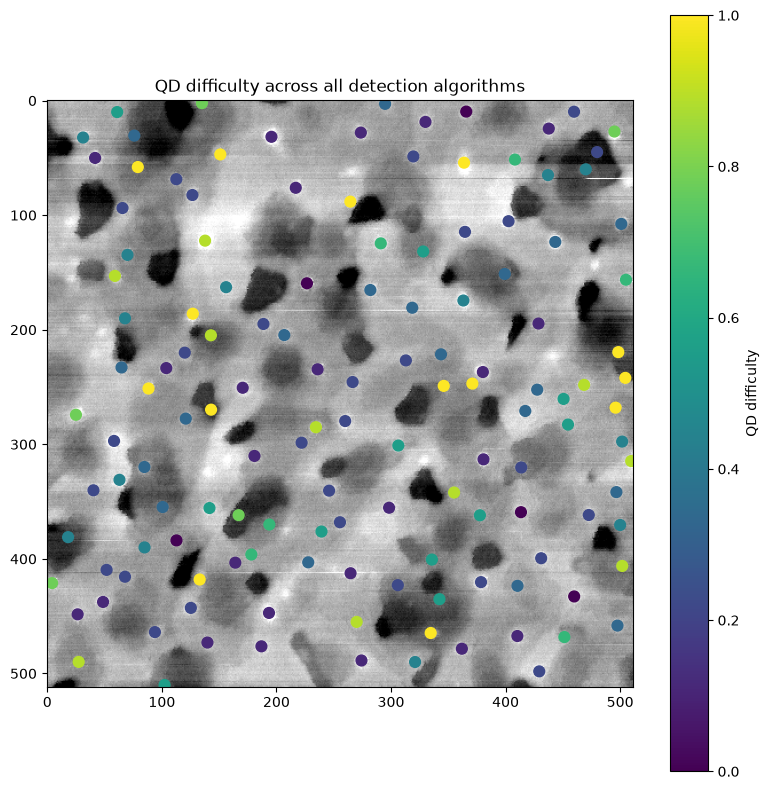

In [51]:
fig, ax = plt.subplots(figsize=(8, 8))

vmin, vmax = np.nanpercentile(image, [1, 99])

ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)

scatter = ax.scatter(
    qd_df["cx"],
    qd_df["cy"],
    c=qd_df["difficulty"],
    cmap="viridis",
    s=60,
)

fig.colorbar(scatter, ax=ax, label="QD difficulty")

ax.set_title("QD difficulty across all detection algorithms")

plt.tight_layout()
plt.show()

# Evaluating QD probabilty of detection given some of its property

Select top 5 algorithms to be working with based on their F1 scores. Loss function for the new model will be getting trained on them.

In [30]:
top5 = ["U-Net", "Watershed", "Chambolle", "Otsu", "LoG"]

## Probability of detecting a dot given its height 

In [31]:
import QD_analysis as qa
import importlib
importlib.reload(qa)

log_height_probability = qa.detection_probability_by_feature(
    qd_df,
    algorithm="LoG",
    feature="height",
)

display(log_height_probability)

,bin,probability,n,feature_mean,feature_median
0,"(-0.001000000185, 8.38e-10]",0.260870,23,6.473111e-10,6.981184e-10
1,"(8.38e-10, 1.07e-09]",0.727273,22,9.665386e-10,9.909398e-10
2,"(1.07e-09, 1.28e-09]",0.782609,23,1.165722e-09,1.158968e-09
3,"(1.28e-09, 1.49e-09]",0.727273,22,1.387709e-09,1.384506e-09
4,"(1.49e-09, 1.71e-09]",0.818182,22,1.621492e-09,1.621352e-09
5,"(1.71e-09, 2.65e-09]",0.782609,23,2.069865e-09,2.067678e-09


In [32]:
for algorithm_name, result in algorithm_results.items():
    safe_name = algorithm_name.lower().replace(" ", "_").replace("-", "_")

    centres = result["after_height_filter"]["centres"]
    detected, distance = qa.match_detections(qd_df, centres, tolerance=3.0)

    qd_df[f"{safe_name}_after"] = detected
    qd_df[f"{safe_name}_after_distance"] = distance

print([c for c in qd_df.columns if c.endswith("_after")])

['log_after', 'cad_after', 'otsu_after', 'ht_after', 'pmad_after', 'pc_after', 'sift_after', 'ws_after', 'gw_after']


In [ ]:
# LOAD U-NET
model = tf.keras.models.load_model(PROJECT_ROOT / "Detection/Binary-Unet/qd_unet_fold1.keras", compile=False)




detected, distance = qa.match_detections(qd_df, unet_centres, tolerance=3.0)

qd_df["unet_after"] = detected
qd_df["unet_after_distance"] = distance

NameError: name 'unet_centres' is not defined

### Plotting probability of detecting a dot given its height continuously (involves interpolation)

KeyError: "['u_net_after'] not in index"

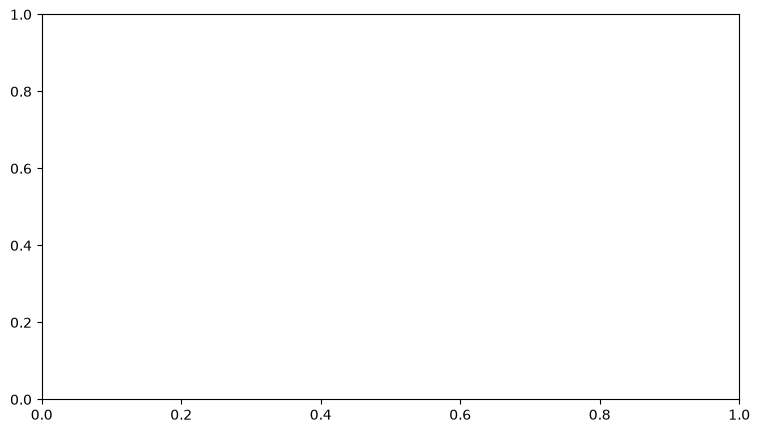

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

for algorithm in top5:
    result = qa.detection_probability_by_feature(
        qd_df,
        algorithm,
        "height",
        n_bins=6,
    )

    ax.plot(
        result["feature_mean"],
        result["probability"],
        marker="o",
        label=algorithm,
    )

ax.set_ylim(0, 1.05)
ax.set_xlabel("QD height")
ax.set_ylabel("P(detected | height)")
ax.set_title("Probability of QD detection given height")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Probability of detecting a dot given its local contrast 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for algorithm in top5:
    result = detection_probability_by_feature(
        qd_df,
        algorithm,
        "local_contrast",
        n_bins=6,
    )

    ax.plot(
        result["feature_mean"],
        result["probability"],
        marker="o",
        label=algorithm,
    )

ax.set_ylim(0, 1.05)
ax.set_xlabel("Local QD contrast")
ax.set_ylabel("P(detected | local contrast)")
ax.set_title("Probability of QD detection given local contrast")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Probability of detecting a dot given its position:  On-pit vs Off-pit

In [ ]:
pit_probability_df = qa.detection_probability_by_pit(
    qd_df,
    top5,
)

display(pit_probability_df)

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(top5))
width = 0.35

off_pit = (
    pit_probability_df[
        pit_probability_df["location"] == "Off pit"
    ]
    .set_index("algorithm")
    .loc[top5]
)

on_pit = (
    pit_probability_df[
        pit_probability_df["location"] == "On pit"
    ]
    .set_index("algorithm")
    .loc[top5]
)

ax.bar(x - width/2, off_pit["probability"], width, label="Off pit")
ax.bar(x + width/2, on_pit["probability"], width, label="On pit")

ax.set_xticks(x)
ax.set_xticklabels(top5)
ax.set_ylim(0, 1)
ax.set_ylabel("P(detected)")
ax.set_title("Probability of detection for QDs on and off pits")
ax.legend()

plt.tight_layout()
plt.show()

# Multivariable detection probability

In [ ]:
unet_probability_model = qa.fit_multivariable_detection_model(
    qd_df,
    "U-Net",
)

# Complementary probabilities 

In [ ]:
for algorithm in top5:
    if algorithm == "U-Net":
        continue

    p = qa.probability_detected_given_missed(
        qd_df,
        detector=algorithm,
        missed_by="U-Net",
    )

    print(
        f"P({algorithm} detects | U-Net misses) = {p:.3f}"
    )

In [ ]:
rescue_matrix = build_rescue_matrix(
    qd_df,
    top5,
)

display(rescue_matrix)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    rescue_matrix,
    vmin=0,
    vmax=1,
    cmap="viridis",
)

ax.set_xticks(np.arange(len(top5)))
ax.set_xticklabels(top5, rotation=30, ha="right")

ax.set_yticks(np.arange(len(top5)))
ax.set_yticklabels(top5)

for i in range(len(top5)):
    for j in range(len(top5)):
        value = rescue_matrix.iloc[i, j]

        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
            )

ax.set_xlabel("Algorithm that missed the QD")
ax.set_ylabel("Algorithm detecting the QD")
ax.set_title("Conditional detector complementarity")

fig.colorbar(
    im,
    ax=ax,
    label="P(row algorithm detects | column algorithm misses)",
)

plt.tight_layout()
plt.show()

In [ ]:
unet_missed_on_pit = qd_df[
    (~qd_df["u_net_after"])
    & (qd_df["on_pit"])
]

for algorithm in top5:
    if algorithm == "U-Net":
        continue

    col = f"{safe_name(algorithm)}_after"

    print(
        algorithm,
        unet_missed_on_pit[col].mean(),
    )